In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import asyncio
import ipywidgets as widgets
from IPython.display import display


from scipy.optimize import least_squares
from scipy.ndimage import gaussian_filter1d
from scipy.integrate import simpson
from scipy.interpolate import PchipInterpolator
from scipy.special import voigt_profile

In [2]:
# ============================================================
# SELECT AN .XY FILE
# Run All will pause at the next cell until a file is uploaded
# ============================================================

xy_upload = widgets.FileUpload(
    accept=".xy",
    multiple=False,
    description="Choose .xy file",
)

# Create an asynchronous event that will be completed after upload
upload_future = asyncio.get_running_loop().create_future()


def handle_upload(change):
    """Resume the notebook when an uploaded file becomes available."""

    if change["new"] and not upload_future.done():
        upload_future.set_result(change["new"])


xy_upload.observe(
    handle_upload,
    names="value",
)

display(xy_upload)

print(
    "Waiting for an .xy file...\n"
    "Click the button above and select a file."
)

FileUpload(value={}, accept='.xy', description='Choose .xy file')

Waiting for an .xy file...
Click the button above and select a file.


In [3]:
# ============================================================
# WAIT FOR THE UPLOAD AND LOAD THE SPECTRUM
# ============================================================


# This pauses Run All without raising an error.
uploaded_value = await upload_future

print("Upload received. Reading spectrum...")


# ------------------------------------------------------------
# Handle different ipywidgets upload formats
# ------------------------------------------------------------

if isinstance(uploaded_value, (tuple, list)):
    uploaded_file = uploaded_value[0]
    legacy_filename = None

elif isinstance(uploaded_value, dict):
    # Current format: one file-record dictionary
    if "content" in uploaded_value:
        uploaded_file = uploaded_value
        legacy_filename = None

    # Older format: {"filename.xy": {"content": ...}}
    else:
        legacy_filename, uploaded_file = next(
            iter(uploaded_value.items())
        )

else:
    raise TypeError(
        "Unexpected upload format: "
        f"{type(uploaded_value)}"
    )


# ------------------------------------------------------------
# Obtain the filename
# ------------------------------------------------------------

uploaded_name = getattr(
    uploaded_file,
    "name",
    None,
)

if uploaded_name is None and hasattr(uploaded_file, "get"):
    uploaded_name = uploaded_file.get("name")

if uploaded_name is None:
    uploaded_name = legacy_filename

if uploaded_name is None:
    uploaded_name = "uploaded_spectrum.xy"


# ------------------------------------------------------------
# Obtain the file contents
# ------------------------------------------------------------

uploaded_content = getattr(
    uploaded_file,
    "content",
    None,
)

if uploaded_content is None and hasattr(uploaded_file, "get"):
    uploaded_content = uploaded_file.get("content")

if uploaded_content is None:
    raise RuntimeError(
        "The uploaded file contents could not be read."
    )


if Path(uploaded_name).suffix.lower() != ".xy":
    raise ValueError("The selected file must have an .xy extension.")


# ------------------------------------------------------------
# Decode the .xy file directly in memory
# ------------------------------------------------------------

text = bytes(uploaded_content).decode(
    "utf-8",
    errors="ignore",
)

spectrum_rows = []

for line in text.splitlines():
    stripped = line.strip()

    # Ignore blank lines and metadata beginning with #
    if not stripped or stripped.startswith("#"):
        continue

    columns = stripped.split()

    if len(columns) < 2:
        continue

    try:
        binding_energy = float(columns[0])
        intensity = float(columns[1])
    except ValueError:
        continue

    if np.isfinite(binding_energy) and np.isfinite(intensity):
        spectrum_rows.append(
            (binding_energy, intensity)
        )


if not spectrum_rows:
    raise ValueError(
        "No valid numeric spectrum data were found in the .xy file."
    )


# ------------------------------------------------------------
# Create variables expected by the fitting notebook
# ------------------------------------------------------------

df = pd.DataFrame(
    spectrum_rows,
    columns=[
        "Binding Energy (eV)",
        "Intensity",
    ],
)

base_name = Path(uploaded_name).stem

x_original = df["Binding Energy (eV)"].to_numpy(
    dtype=float
)

y_original = df["Intensity"].to_numpy(
    dtype=float
)


print("\nXY FILE LOADED SUCCESSFULLY\n")
print(f"File: {uploaded_name}")
print(f"Spectrum name: {base_name}")
print(f"Number of points: {len(df)}")
print(
    "Binding-energy range: "
    f"{x_original.min():.3f} to "
    f"{x_original.max():.3f} eV"
)

display(df.head())

Upload received. Reading spectrum...

XY FILE LOADED SUCCESSFULLY

File: Nb3d W201 Pristine.xy
Spectrum name: Nb3d W201 Pristine
Number of points: 201
Binding-energy range: 195.000 to 215.000 eV


,Binding Energy (eV),Intensity
0,215.0,20320.436
1,214.9,19669.656
2,214.8,20494.830
3,214.7,19978.502
4,214.6,20048.330


# GENERATE SHIRLEY BACKGROUND


In [4]:
def auto_shirley_window(
    x,
    y,
    smooth_fraction=0.04,
    threshold_fraction=0.015,
    pad_fraction=0.06,
):
    """
    Propose a Shirley window around the detected peak envelope.

    The returned endpoints should be inspected manually before
    quantitative analysis.
    """

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    order = np.argsort(x)
    x_sorted = x[order]
    y_sorted = y[order]

    n = len(y_sorted)

    window = max(5, int(round(n * smooth_fraction)))

    if window % 2 == 0:
        window += 1

    largest_odd_window = n if n % 2 == 1 else n - 1
    window = min(window, largest_odd_window)

    half_window = window // 2
    kernel = np.ones(window, dtype=float) / window

    # Avoid zero-padding artifacts at the two data boundaries.
    y_padded = np.pad(
        y_sorted,
        pad_width=half_window,
        mode="edge"
    )

    y_smooth = np.convolve(
        y_padded,
        kernel,
        mode="valid"
    )

    edge_points = max(3, int(round(n * 0.08)))

    y_lowBE = np.median(y_smooth[:edge_points])
    y_highBE = np.median(y_smooth[-edge_points:])

    rough_baseline = np.linspace(
        y_lowBE,
        y_highBE,
        n
    )

    residual = y_smooth - rough_baseline
    positive_residual = np.maximum(residual, 0.0)

    residual_max = np.max(positive_residual)

    if residual_max <= 0:
        return float(x_sorted[0]), float(x_sorted[-1])

    active = np.flatnonzero(
        positive_residual
        > threshold_fraction * residual_max
    )

    if len(active) == 0:
        peak_index = int(np.argmax(positive_residual))
        active = np.array([peak_index])

    pad_points = max(2, int(round(n * pad_fraction)))

    left = max(0, active[0] - pad_points)
    right = min(n - 1, active[-1] + pad_points)

    return float(x_sorted[left]), float(x_sorted[right])

In [5]:
def shirley_background(
    x,
    y,
    fit_min=None,
    fit_max=None,
    endpoint_points=5,
    max_iter=500,
    rtol=1e-8,
    atol=1e-6,
):
    """
    Calculate a classic iterative Shirley background over a limited
    near-peak XPS energy range.

    Parameters
    ----------
    x : array-like
        Binding energy values.
    y : array-like
        Intensity values, preferably corrected for analyzer transmission.
    fit_min, fit_max : float, optional
        Binding-energy limits of the Shirley region.
    endpoint_points : int
        Number of points used to estimate each endpoint intensity.
    max_iter : int
        Maximum number of Shirley iterations.
    rtol, atol : float
        Relative and absolute convergence tolerances.

    Returns
    -------
    background : ndarray
        Shirley background in the original data order. Values outside
        the selected range are NaN.
    """

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if x.ndim != 1 or y.ndim != 1:
        raise ValueError("x and y must be one-dimensional arrays.")

    if len(x) != len(y):
        raise ValueError("x and y must have the same length.")

    if len(x) < 3:
        raise ValueError("At least three data points are required.")

    if not np.all(np.isfinite(x)) or not np.all(np.isfinite(y)):
        raise ValueError("x and y must contain only finite values.")

    # Sort from low binding energy to high binding energy.
    order = np.argsort(x)
    x_sorted = x[order]
    y_sorted = y[order]

    # Duplicate energy values make integration ambiguous.
    if np.any(np.diff(x_sorted) <= 0):
        raise ValueError("Binding-energy values must be unique.")

    if fit_min is None:
        fit_min = float(x_sorted[0])

    if fit_max is None:
        fit_max = float(x_sorted[-1])

    fit_min, fit_max = sorted((float(fit_min), float(fit_max)))

    fit_mask = (x_sorted >= fit_min) & (x_sorted <= fit_max)

    if np.count_nonzero(fit_mask) < 3:
        raise ValueError(
            "The Shirley fit range must contain at least three points."
        )

    x_fit = x_sorted[fit_mask]
    y_fit = y_sorted[fit_mask]

    n_endpoint = min(
        int(endpoint_points),
        max(1, len(y_fit) // 4)
    )

    # Median endpoint levels reduce sensitivity to individual noisy points.
    y_lowBE = float(np.median(y_fit[:n_endpoint]))
    y_highBE = float(np.median(y_fit[-n_endpoint:]))

    # Initial approximation.
    bg = np.full_like(y_fit, y_lowBE, dtype=float)

    converged = False

    for iteration in range(1, max_iter + 1):
        bg_old = bg.copy()

        # Do not clip negative values; retain the iterative Shirley equation.
        net = y_fit - bg_old

        # Cumulative trapezoidal integral from low BE to high BE.
        dx = np.diff(x_fit)
        trapezoids = 0.5 * (net[:-1] + net[1:]) * dx

        cumulative_area = np.concatenate(
            ([0.0], np.cumsum(trapezoids))
        )

        total_area = cumulative_area[-1]

        if (
            not np.isfinite(total_area)
            or abs(total_area) < np.finfo(float).eps
        ):
            raise RuntimeError(
                "The net Shirley area is zero or non-finite. "
                "Check the selected endpoints."
            )

        bg = (
            y_lowBE
            + (y_highBE - y_lowBE)
            * cumulative_area
            / total_area
        )

        if np.allclose(bg, bg_old, rtol=rtol, atol=atol):
            converged = True
            print(f"Converged after {iteration} iterations")
            break

    if not converged:
        raise RuntimeError(
            f"Shirley background did not converge after "
            f"{max_iter} iterations."
        )

    bg_sorted = np.full(y_sorted.shape, np.nan, dtype=float)
    bg_sorted[fit_mask] = bg

    background = np.empty_like(bg_sorted)
    background[order] = bg_sorted

    return background

In [6]:
# Only divide by transmission if Count/s has not already been corrected.
y_for_analysis = y_original
# y_for_analysis = count_per_second / transmission

SHIRLEY_MIN_BE, SHIRLEY_MAX_BE = auto_shirley_window(
    x_original,
    y_for_analysis
)

print(
    f"Proposed Shirley window: "
    f"{SHIRLEY_MIN_BE:.2f} to {SHIRLEY_MAX_BE:.2f} eV"
)

shirley = shirley_background(
    x_original,
    y_for_analysis,
    fit_min=SHIRLEY_MIN_BE,
    fit_max=SHIRLEY_MAX_BE,
    endpoint_points=5
)

corrected = y_for_analysis - shirley

Proposed Shirley window: 200.30 to 213.60 eV
Converged after 7 iterations


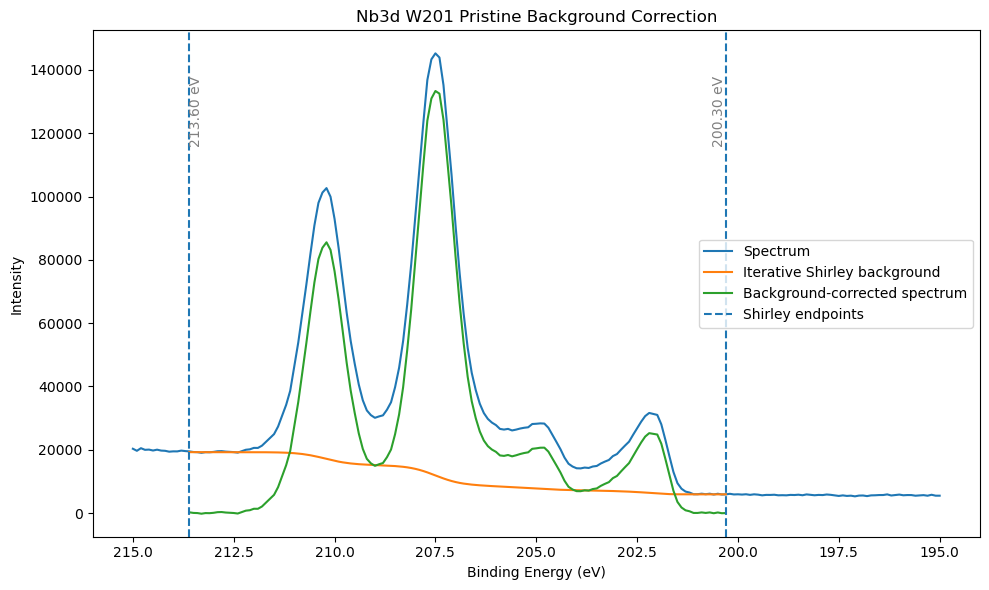

In [7]:
plt.figure(figsize=(10, 6))

plt.plot(
    x_original,
    y_for_analysis,
    label="Spectrum"
)

plt.plot(
    x_original,
    shirley,
    label="Iterative Shirley background"
)

plt.plot(
    x_original,
    corrected,
    label="Background-corrected spectrum"
)

plt.axvline(
    SHIRLEY_MIN_BE,
    linestyle="--",
    label="Shirley endpoints"
)

plt.axvline(
    SHIRLEY_MAX_BE,
    linestyle="--"
)

y_top = np.max(y_original)

plt.text(SHIRLEY_MIN_BE, y_top * 0.95, f"{SHIRLEY_MIN_BE:.2f} eV",
         rotation=90, va="top", ha="right", fontsize=10, color="gray")

plt.text(SHIRLEY_MAX_BE, y_top * 0.95, f"{SHIRLEY_MAX_BE:.2f} eV",
         rotation=90, va="top", ha="left", fontsize=10, color="gray")
plt.title(f"{base_name} Background Correction")
plt.xlabel("Binding Energy (eV)")
plt.ylabel("Intensity")
plt.gca().invert_xaxis()
plt.legend()
plt.tight_layout()
plt.show()


# Advanced single-spectrum Nb 3d fitting pipeline

This notebook still fits **one CSV spectrum at a time** and retains the sequence:

1. adaptive Shirley background,
2. fully coupled nonlinear fit,
3. post-fit binding-energy shift,
4. area, uncertainty, residual, and stability reporting.

The revised model adds the following physically motivated improvements without
multiplying any fitted area, position, or width by an empirical correction ratio:

- all areas, positions, FWHMs, line-shape parameters, and residual-baseline
  parameters are optimized simultaneously;
- the oxide doublets use a true Voigt profile rather than a linear
  pseudo-Voigt approximation;
- the metallic asymmetric peak smoothing is defined in electron-volts rather
  than array-index units;
- a tightly bounded residual offset and slope absorb small Shirley-background
  mismatch without contributing to any species area;
- mild region balancing prevents the dominant Nb2O5 peak from completely
  controlling the objective;
- physically motivated soft position and shape priors are retained;
- multistart fitting uses a coarse screening stage followed by refinement;
- profile-likelihood and bootstrap diagnostics are available as optional cells;
- Shirley-background sensitivity remains explicitly reported.

No species curve is prevented from overlapping another species curve.


In [8]:
# ============================================================
# PREPARE THE BACKGROUND-CORRECTED DATA
#
# The corrected data are not shifted upward. A bounded residual
# offset and slope are fitted simultaneously later. Those baseline
# terms are excluded from all reported species areas.
# ============================================================

x = np.asarray(x_original, dtype=float)
y = np.asarray(corrected, dtype=float)

mask = (
    (x >= SHIRLEY_MIN_BE)
    & (x <= SHIRLEY_MAX_BE)
    & np.isfinite(x)
    & np.isfinite(y)
)

x = x[mask]
y = y[mask]

order = np.argsort(x)
x = x[order]
y = y[order]

intensity_shift = 0.0
x_centered = x - np.mean(x)

print(f"Fitting window: {x.min():.3f} to {x.max():.3f} eV")
print("Artificial corrected-intensity shift: disabled")
print(f"Minimum corrected intensity: {np.min(y):.6f}")


Fitting window: 200.300 to 213.600 eV
Artificial corrected-intensity shift: disabled
Minimum corrected intensity: -202.328714


In [9]:
# ============================================================
# PHYSICAL CONSTANTS AND LINE SHAPES
# ============================================================

SPLIT = 2.72
RATIO = 2.0 / 3.0

# Retained only to preserve the existing metallic-width convention.
METAL_FWHM_CALIBRATION = np.mean([
    0.81600 / 1.72100,
    0.63663 / 1.34900,
    0.60000 / 1.28700,
    0.58000 / 1.25200,
    0.59000 / 1.25600,
    0.55000 / 1.12500,
    0.57000 / 1.22500,
])

def metal_internal_to_fwhm(internal_width):
    return float(internal_width) * METAL_FWHM_CALIBRATION

def metal_fwhm_to_internal(fwhm):
    return float(fwhm) / METAL_FWHM_CALIBRATION


def true_voigt_from_fwhm_eta(x_values, center, fwhm, eta):
    """
    True Voigt profile parameterized by an approximate total FWHM and
    Lorentzian fraction eta.

    The Olivero-Longbothum Voigt-width approximation is inverted so that
    the resulting Voigt profile has approximately the requested total FWHM.
    """
    x_values = np.asarray(x_values, dtype=float)
    fwhm = max(float(fwhm), 1e-8)
    eta = float(np.clip(eta, 0.0, 1.0))

    lorentz_fwhm = max(eta * fwhm, 1e-8)

    inside = (
        (fwhm - 0.5346 * lorentz_fwhm) ** 2
        - 0.2166 * lorentz_fwhm ** 2
    )
    gaussian_fwhm = np.sqrt(max(inside, 1e-12))

    sigma = gaussian_fwhm / 2.354820045
    gamma = lorentz_fwhm / 2.0

    profile = voigt_profile(x_values - center, sigma, gamma)
    maximum = np.max(profile)

    if not np.isfinite(maximum) or maximum <= 0:
        return np.zeros_like(x_values)

    return profile / maximum


def oxide_doublet_height(x_values, height, center_5_2, shared_fwhm, eta):
    p_5_2 = height * true_voigt_from_fwhm_eta(
        x_values,
        center_5_2,
        shared_fwhm,
        eta,
    )

    p_3_2 = height * RATIO * true_voigt_from_fwhm_eta(
        x_values,
        center_5_2 + SPLIT,
        shared_fwhm,
        eta,
    )

    return p_5_2 + p_3_2


def LA_peak(
    x_values,
    height,
    center,
    internal_width,
    alpha=1.2,
    beta=5.0,
    smoothing_fraction=0.12,
):
    """
    Asymmetric Lorentzian-like metallic line shape.

    Smoothing is converted from electron-volts to array points, so the
    physical shape does not change when the input sampling density changes.
    """
    x_values = np.asarray(x_values, dtype=float)

    gamma = max(float(internal_width) / 2.0, 1e-10)
    lorentz = 1.0 / (1.0 + ((x_values - center) / gamma) ** 2)

    profile = np.zeros_like(x_values, dtype=float)
    low_be = x_values <= center
    profile[low_be] = lorentz[low_be] ** beta
    profile[~low_be] = lorentz[~low_be] ** alpha

    if len(x_values) > 1 and smoothing_fraction > 0:
        sorted_unique = np.sort(np.unique(x_values))
        if len(sorted_unique) > 1:
            step = float(np.median(np.diff(sorted_unique)))
            smoothing_sigma_ev = max(
                smoothing_fraction * metal_internal_to_fwhm(internal_width),
                0.01,
            )
            sigma_points = smoothing_sigma_ev / max(abs(step), 1e-12)
            profile = gaussian_filter1d(
                profile,
                sigma=max(sigma_points, 1e-6),
                mode="nearest",
            )

    maximum = np.max(profile)
    if not np.isfinite(maximum) or maximum <= 0:
        return np.zeros_like(x_values)

    return height * profile / maximum


def metal_doublet_height(x_values, height, center_5_2, internal_width):
    p_5_2 = LA_peak(
        x_values,
        height,
        center_5_2,
        internal_width,
    )

    p_3_2 = LA_peak(
        x_values,
        height * RATIO,
        center_5_2 + SPLIT,
        internal_width,
    )

    return p_5_2 + p_3_2


print(f"Metal FWHM calibration factor = {METAL_FWHM_CALIBRATION:.6f}")
print("Oxide line shape: true Voigt")
print("Metal smoothing: defined in eV, not array-index units")


Metal FWHM calibration factor = 0.471353
Oxide line shape: true Voigt
Metal smoothing: defined in eV, not array-index units


In [10]:
# ============================================================
# AREA-NORMALIZED COMPONENTS
#
# Every fitted area is defined as the numerical integral of that
# species curve over the selected fitting window.
# ============================================================

AREA_GRID = np.linspace(np.min(x), np.max(x), 12000)

def normalize_on_area_grid(unit_curve_on_area_grid):
    area = float(simpson(unit_curve_on_area_grid, x=AREA_GRID))

    if not np.isfinite(area) or abs(area) < 1e-15:
        raise ValueError("Component normalization area is zero or non-finite.")

    return abs(area)


def metal_component(x_values, area, center_5_2, internal_width):
    normalization_curve = metal_doublet_height(
        AREA_GRID,
        1.0,
        center_5_2,
        internal_width,
    )
    normalization = normalize_on_area_grid(normalization_curve)

    requested_curve = metal_doublet_height(
        np.asarray(x_values, dtype=float),
        1.0,
        center_5_2,
        internal_width,
    )

    return float(area) * requested_curve / normalization


def oxide_component(
    x_values,
    area,
    center_5_2,
    shared_oxide_fwhm,
    eta,
):
    normalization_curve = oxide_doublet_height(
        AREA_GRID,
        1.0,
        center_5_2,
        shared_oxide_fwhm,
        eta,
    )
    normalization = normalize_on_area_grid(normalization_curve)

    requested_curve = oxide_doublet_height(
        np.asarray(x_values, dtype=float),
        1.0,
        center_5_2,
        shared_oxide_fwhm,
        eta,
    )

    return float(area) * requested_curve / normalization


In [11]:
# ============================================================
# FULLY COUPLED SIMULTANEOUS MODEL
#
# Parameters:
#  0  Nb metal area
#  1  Nb metal 3d5/2 position
#  2  Nb metal internal width
#  3  shared oxide FWHM
#  4  shared oxide Voigt eta
#  5  NbO area
#  6  NbO 3d5/2 position
#  7  NbO2 area
#  8  NbO2 3d5/2 position
#  9  Nb2O5 area
# 10  Nb2O5 3d5/2 position
# 11  residual baseline offset
# 12  residual baseline slope
#
# Baseline parameters are fitted simultaneously but are not included
# in any species area.
# ============================================================

def component_curves(x_values, p):
    shared_oxide_fwhm = p[3]
    shared_oxide_eta = p[4]

    metal = metal_component(
        x_values,
        area=p[0],
        center_5_2=p[1],
        internal_width=p[2],
    )

    nbo = oxide_component(
        x_values,
        area=p[5],
        center_5_2=p[6],
        shared_oxide_fwhm=shared_oxide_fwhm,
        eta=shared_oxide_eta,
    )

    nbo2 = oxide_component(
        x_values,
        area=p[7],
        center_5_2=p[8],
        shared_oxide_fwhm=shared_oxide_fwhm,
        eta=shared_oxide_eta,
    )

    nb2o5 = oxide_component(
        x_values,
        area=p[9],
        center_5_2=p[10],
        shared_oxide_fwhm=shared_oxide_fwhm,
        eta=shared_oxide_eta,
    )

    return metal, nbo, nbo2, nb2o5


def residual_baseline(x_values, p):
    x_values = np.asarray(x_values, dtype=float)
    return p[11] + p[12] * (x_values - np.mean(x))


def total_model(x_values, p):
    components = np.sum(component_curves(x_values, p), axis=0)
    return components + residual_baseline(x_values, p)


In [12]:
# ============================================================
# STARTING VALUES, SOFT PRIORS, AND PARAMETER BOUNDS
# ============================================================

# ------------------------------------------------------------
# 1. Estimate the total background-corrected spectrum area
# ------------------------------------------------------------

def pchip_integral(x_values, y_values):
    """
    Integrate discrete data using a shape-preserving cubic spline.
    """

    x_values = np.asarray(x_values, dtype=float)
    y_values = np.asarray(y_values, dtype=float)

    valid = np.isfinite(x_values) & np.isfinite(y_values)
    x_values = x_values[valid]
    y_values = y_values[valid]

    order = np.argsort(x_values)
    x_values = x_values[order]
    y_values = y_values[order]

    x_values, unique_indices = np.unique(
        x_values,
        return_index=True,
    )
    y_values = y_values[unique_indices]
    ### SPLINES to estimate the area under the curve
    spline = PchipInterpolator(
        x_values,
        y_values,
        extrapolate=False,
    )

    antiderivative = spline.antiderivative()

    return float(
        abs(
            antiderivative(x_values[-1])
            - antiderivative(x_values[0])
        )
    )


total_area_guess = max(
    pchip_integral(x, y),
    1.0,
)


# ------------------------------------------------------------
# 2. Position and shape priors
# ------------------------------------------------------------


### Agreed upon prior positions for the Nb 3d5/2 species
CENTER_PRIORS = {
    "metal": {"center": 202.20, "sigma": 0.30},
    "nbo":   {"center": 203.70, "sigma": 1.00},
    "nbo2":  {"center": 206.20, "sigma": 1.00},
    "nb2o5": {"center": 207.40, "sigma": 0.40},
}

REFERENCE_METAL_BE = CENTER_PRIORS["metal"]["center"]

SHAPE_PRIORS = {
    "metal_fwhm":  {"center": 0.75, "sigma": 0.25},
    "oxide_fwhm":  {"center": 1.12, "sigma": 0.25},
    "oxide_eta":   {"center": 0.25, "sigma": 0.30},
}

USE_SHAPE_PRIORS = True
PRIOR_STRENGTH = 1.0


# ------------------------------------------------------------
# 3. Initial parameter guesses
# ------------------------------------------------------------

metal_fwhm_guess = SHAPE_PRIORS["metal_fwhm"]["center"]
metal_internal_guess = metal_fwhm_to_internal(
    metal_fwhm_guess
)

shared_oxide_fwhm_guess = SHAPE_PRIORS[
    "oxide_fwhm"
]["center"]

shared_oxide_eta_guess = SHAPE_PRIORS[
    "oxide_eta"
]["center"]

###Percentage of total area assigned to each species. These are only starting guesses.
# Final areas are optimized simultaneously.
initial_fractions = np.array([
    0.14454,  # Nb metal
    0.02357,  # NbO
    0.03829,  # NbO2
    0.79360,  # Nb2O5
])

initial_fractions /= initial_fractions.sum()
initial_areas = total_area_guess * initial_fractions


# ------------------------------------------------------------
# 4. Position bounds
# ------------------------------------------------------------

COMMON_SHIFT_LIMIT = 2.0
RELATIVE_BOUND_MULTIPLIER = 2.5


def center_bounds(species):
    prior = CENTER_PRIORS[species]

    half_width = (
        COMMON_SHIFT_LIMIT
        + RELATIVE_BOUND_MULTIPLIER * prior["sigma"]
    )

    return (
        prior["center"] - half_width,
        prior["center"] + half_width,
    )


metal_bounds = center_bounds("metal")
nbo_bounds = center_bounds("nbo")
nbo2_bounds = center_bounds("nbo2")
nb2o5_bounds = center_bounds("nb2o5")


# ------------------------------------------------------------
# 5. Residual-baseline bounds
# ------------------------------------------------------------

edge_count = max(
    6,
    int(round(0.12 * len(y))),
)

edge_values = np.concatenate([
    y[:edge_count],
    y[-edge_count:],
])

edge_mad = (
    1.4826
    * np.median(
        np.abs(
            edge_values
            - np.median(edge_values)
        )
    )
)

edge_scale = max(
    1e-6,
    edge_mad,
    0.01 * max(float(np.ptp(y)), 1.0),
)

baseline_offset_limit = 3.0 * edge_scale

baseline_slope_limit = (
    baseline_offset_limit
    / max(float(np.ptp(x)), 1e-6)
)


# ------------------------------------------------------------
# 6. Initial parameter vector
# ------------------------------------------------------------

p0 = np.array([
    initial_areas[0],
    CENTER_PRIORS["metal"]["center"],
    metal_internal_guess,

    shared_oxide_fwhm_guess,
    shared_oxide_eta_guess,

    initial_areas[1],
    CENTER_PRIORS["nbo"]["center"],

    initial_areas[2],
    CENTER_PRIORS["nbo2"]["center"],

    initial_areas[3],
    CENTER_PRIORS["nb2o5"]["center"],

    0.0,  # residual baseline offset
    0.0,  # residual baseline slope
], dtype=float)


# ------------------------------------------------------------
# 7. Lower and upper parameter bounds
# ------------------------------------------------------------

maximum_component_area = 2.0 * total_area_guess

lower = np.array([
    0.0,
    metal_bounds[0],
    metal_fwhm_to_internal(0.35),

    0.70,
    0.0,

    0.0,
    nbo_bounds[0],

    0.0,
    nbo2_bounds[0],

    0.0,
    nb2o5_bounds[0],

    -baseline_offset_limit,
    -baseline_slope_limit,
], dtype=float)


upper = np.array([
    maximum_component_area,
    metal_bounds[1],
    metal_fwhm_to_internal(1.20),

    1.55,
    1.0,

    maximum_component_area,
    nbo_bounds[1],

    maximum_component_area,
    nbo2_bounds[1],

    maximum_component_area,
    nb2o5_bounds[1],

    baseline_offset_limit,
    baseline_slope_limit,
], dtype=float)


# ------------------------------------------------------------
# 8. Summary
# ------------------------------------------------------------

labels = [
    "Nb metal",
    "NbO",
    "NbO2",
    "Nb2O5",
]

print("\nINITIAL FIT SETUP\n")

print(f"Estimated total area: {total_area_guess:.2f}")

for label, area in zip(labels, initial_areas):
    print(f"{label:<8} initial area = {area:.2f}")

print(
    f"\nResidual offset limit: "
    f"±{baseline_offset_limit:.6g}"
)

print(
    f"Residual slope limit: "
    f"±{baseline_slope_limit:.6g} intensity/eV"
)


INITIAL FIT SETUP

Estimated total area: 363583.39
Nb metal initial area = 52552.34
NbO      initial area = 8569.66
NbO2     initial area = 13921.61
Nb2O5    initial area = 288539.78

Residual offset limit: ±4006.07
Residual slope limit: ±301.208 intensity/eV


### This may take 1-2 minutes to run

In [13]:
# ============================================================
# MULTI-START, FULLY COUPLED SIMULTANEOUS FIT
# ============================================================

edge_count = max(6, int(round(0.12 * len(y))))
edge_values = np.concatenate([y[:edge_count], y[-edge_count:]])
edge_differences = np.diff(edge_values)

if len(edge_differences) > 0:
    diff_median = np.median(edge_differences)
    noise_sigma = (
        1.4826
        * np.median(np.abs(edge_differences - diff_median))
        / np.sqrt(2.0)
    )
else:
    noise_sigma = np.nan

fallback_noise = max(
    1e-6,
    0.01 * max(float(np.ptp(y)), 1.0),
)

if not np.isfinite(noise_sigma) or noise_sigma <= 0:
    noise_sigma = fallback_noise

sigma = np.full_like(y, noise_sigma, dtype=float)

AREA_INDICES = (0, 5, 7, 9)
CENTER_INDICES = (1, 6, 8, 10)

# Mildly balance chemically informative regions so the dominant Nb2O5
# maximum does not completely determine the objective.
USE_REGION_BALANCING = True
REGION_WEIGHT_CAP = (0.70, 2.00)

def make_region_weights(x_values):
    if not USE_REGION_BALANCING:
        return np.ones_like(x_values, dtype=float)

    x_values = np.asarray(x_values, dtype=float)

    # Broad regions; overlap is still fully allowed in the model.
    boundaries = np.array([
        203.0,
        205.0,
        206.9,
        208.8,
    ])

    region_id = np.digitize(x_values, boundaries)
    weights = np.ones_like(x_values, dtype=float)

    unique_regions = np.unique(region_id)
    target_count = len(x_values) / max(len(unique_regions), 1)

    for rid in unique_regions:
        region_mask = region_id == rid
        count = max(np.count_nonzero(region_mask), 1)
        weight = np.sqrt(target_count / count)
        weights[region_mask] = weight

    weights = np.clip(
        weights,
        REGION_WEIGHT_CAP[0],
        REGION_WEIGHT_CAP[1],
    )

    # Keep the mean squared weight near one.
    weights /= np.sqrt(np.mean(weights ** 2))
    return weights


region_weights = make_region_weights(x)


def shifted_positions_from_parameters(p):
    shift = REFERENCE_METAL_BE - p[1]
    return np.array([p[i] + shift for i in CENTER_INDICES], dtype=float)


def position_prior_residuals(p):
    shifted = shifted_positions_from_parameters(p)

    return np.array([
        (
            shifted[1] - CENTER_PRIORS["nbo"]["center"]
        ) / CENTER_PRIORS["nbo"]["sigma"],
        (
            shifted[2] - CENTER_PRIORS["nbo2"]["center"]
        ) / CENTER_PRIORS["nbo2"]["sigma"],
        (
            shifted[3] - CENTER_PRIORS["nb2o5"]["center"]
        ) / CENTER_PRIORS["nb2o5"]["sigma"],
    ], dtype=float)


def shape_prior_residuals(p):
    if not USE_SHAPE_PRIORS:
        return np.empty(0, dtype=float)

    metal_fwhm = metal_internal_to_fwhm(p[2])

    return np.array([
        (
            metal_fwhm - SHAPE_PRIORS["metal_fwhm"]["center"]
        ) / SHAPE_PRIORS["metal_fwhm"]["sigma"],
        (
            p[3] - SHAPE_PRIORS["oxide_fwhm"]["center"]
        ) / SHAPE_PRIORS["oxide_fwhm"]["sigma"],
        (
            p[4] - SHAPE_PRIORS["oxide_eta"]["center"]
        ) / SHAPE_PRIORS["oxide_eta"]["sigma"],
    ], dtype=float)


def baseline_prior_residuals(p):
    return np.array([
        p[11] / max(baseline_offset_limit / 2.0, 1e-12),
        p[12] / max(baseline_slope_limit / 2.0, 1e-12),
    ], dtype=float)


def data_residual_vector(p):
    raw = (total_model(x, p) - y) / sigma
    return region_weights * raw


def residual_vector(p):
    return np.concatenate([
        data_residual_vector(p),
        PRIOR_STRENGTH * position_prior_residuals(p),
        PRIOR_STRENGTH * shape_prior_residuals(p),
        0.50 * baseline_prior_residuals(p),
    ])

rng = np.random.default_rng(42)
starts = [p0.copy()]

dirichlet_alpha = np.array([3.0, 1.0, 1.0, 8.0])
NUMBER_RANDOM_STARTS = 29

for _ in range(NUMBER_RANDOM_STARTS):
    trial = p0.copy()

    random_fractions = rng.dirichlet(dirichlet_alpha)
    random_total_area = total_area_guess * rng.lognormal(
        mean=0.0,
        sigma=0.15,
    )
    random_areas = random_total_area * random_fractions

    for idx, area in zip(AREA_INDICES, random_areas):
        trial[idx] = area

    common_offset = np.clip(
        rng.normal(0.0, 0.45),
        -COMMON_SHIFT_LIMIT,
        COMMON_SHIFT_LIMIT,
    )

    trial[1] = CENTER_PRIORS["metal"]["center"] + common_offset
    trial[6] = (
        CENTER_PRIORS["nbo"]["center"]
        + common_offset
        + rng.normal(0.0, 0.45 * CENTER_PRIORS["nbo"]["sigma"])
    )
    trial[8] = (
        CENTER_PRIORS["nbo2"]["center"]
        + common_offset
        + rng.normal(0.0, 0.45 * CENTER_PRIORS["nbo2"]["sigma"])
    )
    trial[10] = (
        CENTER_PRIORS["nb2o5"]["center"]
        + common_offset
        + rng.normal(0.0, 0.45 * CENTER_PRIORS["nb2o5"]["sigma"])
    )

    trial[2] = metal_fwhm_to_internal(
        np.clip(
            rng.normal(metal_fwhm_guess, 0.15),
            0.35,
            1.20,
        )
    )

    trial[3] = np.clip(
        rng.normal(shared_oxide_fwhm_guess, 0.16),
        lower[3],
        upper[3],
    )

    trial[4] = np.clip(
        rng.normal(shared_oxide_eta_guess, 0.18),
        lower[4],
        upper[4],
    )

    trial[11] = rng.normal(0.0, baseline_offset_limit / 3.0)
    trial[12] = rng.normal(0.0, baseline_slope_limit / 3.0)

    trial = np.clip(trial, lower + 1e-10, upper - 1e-10)
    starts.append(trial)


# -------------------------------
# Stage 1: coarse screening
# -------------------------------

coarse_candidates = []

print(f"Beginning coarse fitting of {len(starts)} starts...")

for start_number, start in enumerate(starts):
    try:
        result = least_squares(
            residual_vector,
            start,
            bounds=(lower, upper),
            method="trf",
            x_scale="jac",
            loss="soft_l1",
            f_scale=1.0,
            max_nfev=3000,
            ftol=1e-7,
            xtol=1e-7,
            gtol=1e-7,
        )

        if np.all(np.isfinite(result.x)):
            full_score = float(np.mean(residual_vector(result.x) ** 2))
            data_score = float(np.mean(data_residual_vector(result.x) ** 2))

            coarse_candidates.append(
                (full_score, data_score, start_number, result)
            )

    except (ValueError, RuntimeError, FloatingPointError):
        continue

    if (start_number + 1) % 5 == 0:
        print(f"Completed {start_number + 1} of {len(starts)} starts")


if not coarse_candidates:
    raise RuntimeError("All coarse simultaneous fitting starts failed.")

coarse_candidates.sort(key=lambda item: item[0])


# -------------------------------
# Stage 2: refine best solutions
# -------------------------------

NUMBER_TO_REFINE = min(5, len(coarse_candidates))
refined_candidates = []

print(f"\nRefining the best {NUMBER_TO_REFINE} solutions...")

for rank, coarse_candidate in enumerate(
    coarse_candidates[:NUMBER_TO_REFINE],
    start=1,
):
    _, _, original_start_number, coarse_result = coarse_candidate

    try:
        refined_result = least_squares(
            residual_vector,
            coarse_result.x,
            bounds=(lower, upper),
            method="trf",
            x_scale="jac",
            loss="soft_l1",
            f_scale=1.0,
            max_nfev=15000,
            ftol=1e-9,
            xtol=1e-9,
            gtol=1e-9,
        )

        if np.all(np.isfinite(refined_result.x)):
            refined_full_score = float(
                np.mean(residual_vector(refined_result.x) ** 2)
            )
            refined_data_score = float(
                np.mean(data_residual_vector(refined_result.x) ** 2)
            )

            refined_candidates.append(
                (
                    refined_full_score,
                    refined_data_score,
                    original_start_number,
                    refined_result,
                )
            )

            print(
                f"Refinement {rank}: full score = "
                f"{refined_full_score:.8g}"
            )

    except (ValueError, RuntimeError, FloatingPointError):
        continue


candidates = refined_candidates if refined_candidates else coarse_candidates
candidates.sort(key=lambda item: item[0])

best_score, best_data_score, best_start_number, best_result = candidates[0]
popt = best_result.x

print("\nFINAL MULTI-START RESULTS\n")
print(f"Estimated point-noise sigma: {noise_sigma:.6g}")
print(f"Region balancing enabled: {USE_REGION_BALANCING}")
print(f"Successful coarse starts: {len(coarse_candidates)} / {len(starts)}")
print(f"Successful refined fits: {len(refined_candidates)} / {NUMBER_TO_REFINE}")
print(f"Best original starting trial: {best_start_number}")
print(f"Best full penalized score: {best_score:.8g}")
print(f"Best data-only reduced score: {best_data_score:.8g}")
print(f"Residual baseline offset: {popt[11]:+.6g}")
print(f"Residual baseline slope: {popt[12]:+.6g} intensity/eV")

print("\nBest available solutions:")
for rank, (full_score, data_score, start_number, result) in enumerate(
    candidates[:5],
    start=1,
):
    print(
        f"{rank}: full = {full_score:.8g}, "
        f"data = {data_score:.8g}, "
        f"start = {start_number}, "
        f"nfev = {result.nfev}"
    )

Beginning coarse fitting of 30 starts...
Completed 5 of 30 starts
Completed 10 of 30 starts
Completed 15 of 30 starts
Completed 20 of 30 starts
Completed 25 of 30 starts
Completed 30 of 30 starts

Refining the best 5 solutions...
Refinement 1: full score = 14.400068
Refinement 2: full score = 14.405331
Refinement 3: full score = 14.425058
Refinement 4: full score = 14.425815
Refinement 5: full score = 14.427343

FINAL MULTI-START RESULTS

Estimated point-noise sigma: 220.593
Region balancing enabled: True
Successful coarse starts: 30 / 30
Successful refined fits: 5 / 5
Best original starting trial: 3
Best full penalized score: 14.400068
Best data-only reduced score: 15.254439
Residual baseline offset: -598.957
Residual baseline slope: -28.3898 intensity/eV

Best available solutions:
1: full = 14.400068, data = 15.254439, start = 3, nfev = 13
2: full = 14.405331, data = 15.260096, start = 15, nfev = 14
3: full = 14.425058, data = 15.281029, start = 21, nfev = 11
4: full = 14.425815, dat

In [14]:
# ============================================================
# EXTRACT UNSHIFTED FIT PARAMETERS
# ============================================================

component_names = ["Nb metal", "NbO", "NbO2", "Nb2O5"]

area_indices = (0, 5, 7, 9)
center_indices = (1, 6, 8, 10)

# Extract fitted quantities
fitted_areas = popt[list(area_indices)]
unshifted_centers = popt[list(center_indices)]

# Shared shape parameters
metal_fwhm_reported = metal_internal_to_fwhm(popt[2])
shared_oxide_fwhm = popt[3]
shared_oxide_eta = popt[4]

# Residual baseline parameters
baseline_offset = popt[11]
baseline_slope = popt[12]

# Convenience variables
total_fitted_area = fitted_areas.sum()

reported_fwhms = np.array([
    metal_fwhm_reported,
    shared_oxide_fwhm,
    shared_oxide_fwhm,
    shared_oxide_fwhm,
])

print(f"\nTotal fitted species area = {fitted_areas.sum():.2f}")
print(f"Residual baseline offset = {popt[11]:+.6g}")
print(f"Residual baseline slope = {popt[12]:+.6g} intensity/eV")
print(f"Shared oxide Voigt eta = {shared_oxide_eta:.4f}")
print("Doublet separation = 2.72 eV")
print("3d5/2 : 3d3/2 area ratio = 3 : 2")



Total fitted species area = 371714.49
Residual baseline offset = -598.957
Residual baseline slope = -28.3898 intensity/eV
Shared oxide Voigt eta = 0.1704
Doublet separation = 2.72 eV
3d5/2 : 3d3/2 area ratio = 3 : 2


# Binding-energy shift

The simultaneous fit is completed first. Then the same shift used in the original
notebook is applied:

```python
shift = 202.200 - fitted_metal_position
```

The same constant is added to every species position and to the plotted energy axis.

In [15]:
# ============================================================
# APPLY THE POST-FIT ENERGY SHIFT
# ============================================================

energy_shift = REFERENCE_METAL_BE - popt[1]

shifted_centers = unshifted_centers + energy_shift
x_shifted = x + energy_shift

# ------------------------------------------------------------
# Create summary table
# ------------------------------------------------------------

shift_table = pd.DataFrame({
    "Species": component_names,
    "Unshifted 3d5/2 (eV)": np.round(unshifted_centers, 3),
    "Shifted 3d5/2 (eV)": np.round(shifted_centers, 3),
    "FWHM (eV)": np.round(reported_fwhms, 3),
})

print(f"\n{base_name} FIT RESULTS\n")

display(shift_table)

print(f"\nApplied energy shift = {energy_shift:+.3f} eV")


Nb3d W201 Pristine FIT RESULTS



,Species,Unshifted 3d5/2 (eV),Shifted 3d5/2 (eV),FWHM (eV)
0,Nb metal,202.078,202.200,0.840
1,NbO,203.987,204.109,1.136
2,NbO2,206.050,206.172,1.136
3,Nb2O5,207.501,207.623,1.136



Applied energy shift = +0.122 eV


In [16]:
# ============================================================
# RAW AREA VERIFICATION USING SIMPSON
# ============================================================

dense_components = component_curves(AREA_GRID, popt)
dense_species_total = np.sum(dense_components, axis=0)
dense_baseline = residual_baseline(AREA_GRID, popt)

raw_areas = np.array([
    abs(simpson(curve, x=AREA_GRID))
    for curve in dense_components
])

area_table = pd.DataFrame({
    "Component": component_names,
    "Fitted area": fitted_areas,
    "Raw integrated area (Simpson)": raw_areas,
    "Difference": raw_areas - fitted_areas,
})

display(area_table)

corrected_data_signed_area = float(simpson(y, x=x))
baseline_signed_area = float(simpson(dense_baseline, x=AREA_GRID))

# ------------------------------------------------------------
# Oxide line-shape composition
# ------------------------------------------------------------

gaussian_percent = (1.0 - shared_oxide_eta) * 100.0
lorentzian_percent = shared_oxide_eta * 100.0

print("\nOxide Line Shape")
print("-" * 40)
print("The oxide peaks (NbO, NbO₂, and Nb₂O₅) share a common")
print("pseudo-Voigt line shape consisting of:")
print(f"  - Gaussian   : {gaussian_percent:.1f}%")
print(f"  - Lorentzian : {lorentzian_percent:.1f}%")

print(f"\nSigned corrected-data area = {corrected_data_signed_area:.2f}")
print(f"Sum of raw species areas  = {raw_areas.sum():.3f}")
print(f"Residual baseline area    = {baseline_signed_area:.3f}")
print(
    "Species + residual baseline = "
    f"{raw_areas.sum() + baseline_signed_area:.2f}"
)


,Component,Fitted area,Raw integrated area (Simpson),Difference
0,Nb metal,65911.264314,65911.264314,0.000000e+00
1,NbO,6335.110751,6335.110751,1.818989e-12
2,NbO2,20376.754268,20376.754268,0.000000e+00
3,Nb2O5,279091.361794,279091.361794,5.820766e-11



Oxide Line Shape
----------------------------------------
The oxide peaks (NbO, NbO₂, and Nb₂O₅) share a common
pseudo-Voigt line shape consisting of:
  - Gaussian   : 83.0%
  - Lorentzian : 17.0%

Signed corrected-data area = 363576.95
Sum of raw species areas  = 371714.491
Residual baseline area    = -7966.129
Species + residual baseline = 363748.36


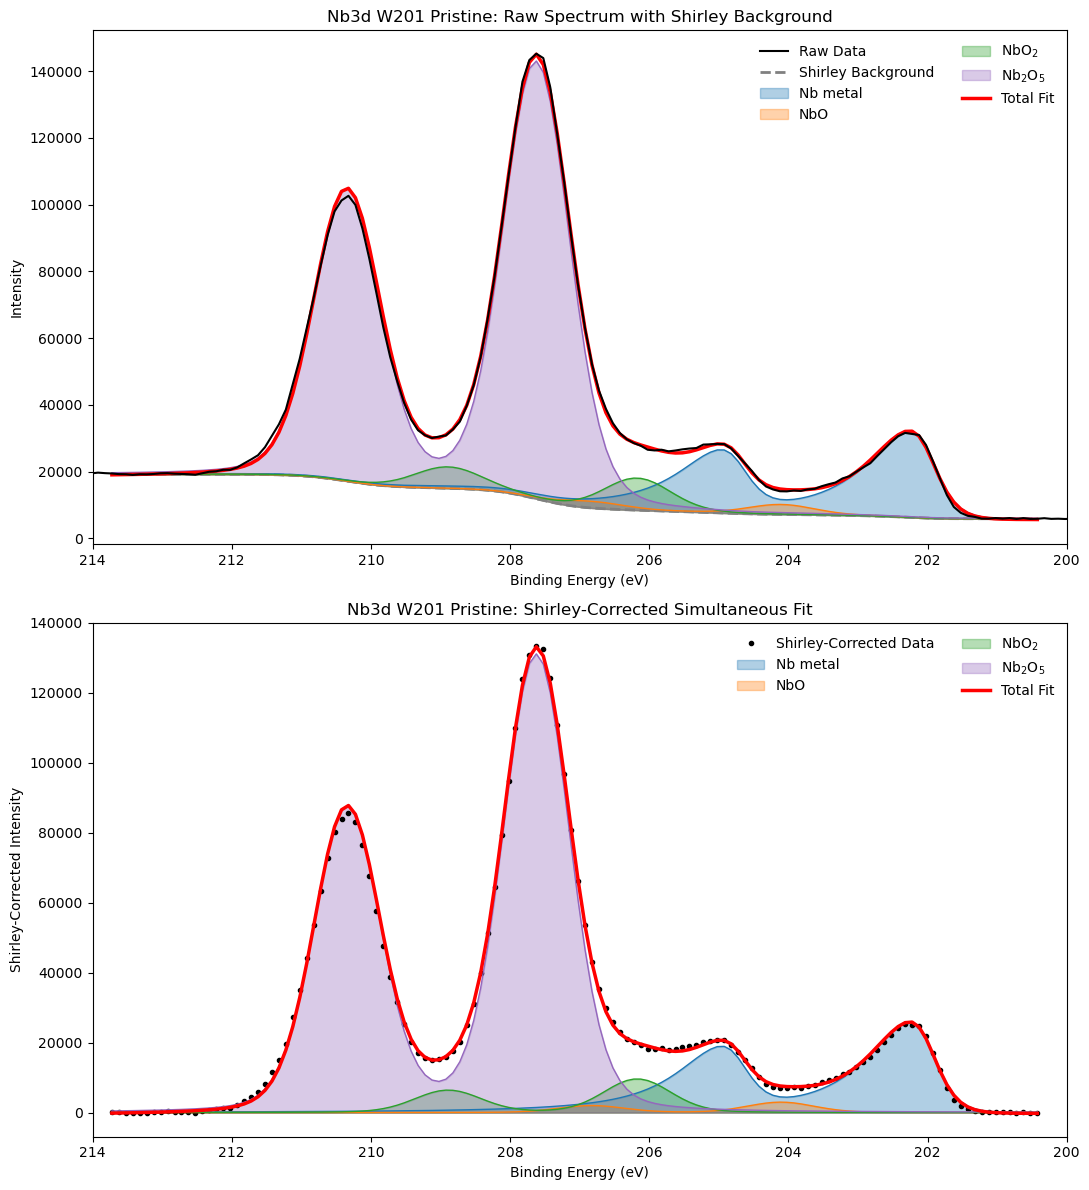

In [17]:
# ============================================================
# FINAL FIT SUMMARY PLOTS (NO RESIDUAL BASELINE)
# WITH SPECIES LEGENDS, SHADED AREAS, AND CROPPED X-RANGE
# ============================================================

# Evaluate model
model_at_x = total_model(x, popt)
nb_metal, nbo, nbo2, nb2o5 = component_curves(x, popt)

# ------------------------------------------------------------
# Shirley background on fitting grid
# ------------------------------------------------------------

valid_bg = np.isfinite(shirley)
bg_order = np.argsort(x_original[valid_bg])

shirley_at_x = np.interp(
    x,
    x_original[valid_bg][bg_order],
    shirley[valid_bg][bg_order],
)

raw_x_shifted = x_original + energy_shift

# Components with Shirley background
nb_metal_bg = nb_metal + shirley_at_x
nbo_bg      = nbo      + shirley_at_x
nbo2_bg     = nbo2     + shirley_at_x
nb2o5_bg    = nb2o5    + shirley_at_x

total_fit_bg = model_at_x + shirley_at_x

# ------------------------------------------------------------
# Colors
# ------------------------------------------------------------

colors = {
    "metal": "#1f77b4",
    "nbo": "#ff7f0e",
    "nbo2": "#2ca02c",
    "nb2o5": "#9467bd",
}

# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------

fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(11, 12),
    sharex=True,
)

# ============================================================
# TOP: RAW DATA
# ============================================================

ax1.plot(
    raw_x_shifted,
    y_original,
    color="black",
    lw=1.5,
    label="Raw Data",
    zorder=10,
)

ax1.plot(
    raw_x_shifted,
    shirley,
    "--",
    color="gray",
    lw=2,
    label="Shirley Background",
)

for curve_bg, color, label in zip(
    [nb_metal_bg, nbo_bg, nbo2_bg, nb2o5_bg],
    [
        colors["metal"],
        colors["nbo"],
        colors["nbo2"],
        colors["nb2o5"],
    ],
    [
        "Nb metal",
        "NbO",
        r"NbO$_2$",
        r"Nb$_2$O$_5$",
    ],
):
    ax1.fill_between(
        x_shifted,
        shirley_at_x,
        curve_bg,
        color=color,
        alpha=0.35,
        label=label,
    )

    ax1.plot(
        x_shifted,
        curve_bg,
        color=color,
        lw=1,
    )

ax1.plot(
    x_shifted,
    total_fit_bg,
    color="red",
    lw=2.5,
    label="Total Fit",
)

ax1.set_title(
    f"{base_name}: Raw Spectrum with Shirley Background"
)

ax1.set_ylabel("Intensity")
ax1.set_xlabel("Binding Energy (eV)")
ax1.tick_params(axis="x", labelbottom=True)

ax1.legend(
    frameon=False,
    ncol=2,
)

# ============================================================
# BOTTOM: SHIRLEY-CORRECTED DATA
# ============================================================

ax2.plot(
    x_shifted,
    y,
    "ko",
    markersize=3,
    label="Shirley-Corrected Data",
)

for curve, color, label in zip(
    [nb_metal, nbo, nbo2, nb2o5],
    [
        colors["metal"],
        colors["nbo"],
        colors["nbo2"],
        colors["nb2o5"],
    ],
    [
        "Nb metal",
        "NbO",
        r"NbO$_2$",
        r"Nb$_2$O$_5$",
    ],
):
    ax2.fill_between(
        x_shifted,
        0,
        curve,
        color=color,
        alpha=0.35,
        label=label,
    )

    ax2.plot(
        x_shifted,
        curve,
        color=color,
        lw=1,
    )

ax2.plot(
    x_shifted,
    model_at_x,
    color="red",
    lw=2.5,
    label="Total Fit",
)

ax2.set_title(
    f"{base_name}: Shirley-Corrected Simultaneous Fit"
)

ax2.set_xlabel("Binding Energy (eV)")
ax2.set_ylabel("Shirley-Corrected Intensity")

ax2.legend(
    frameon=False,
    ncol=2,
)

# ------------------------------------------------------------
# Crop to the Nb 3d region
# High binding energy on the left
# ------------------------------------------------------------

ax1.set_xlim(214, 200)

plt.tight_layout()
plt.show()

# FINAL TABLE AND RESIDUAL GRAPH

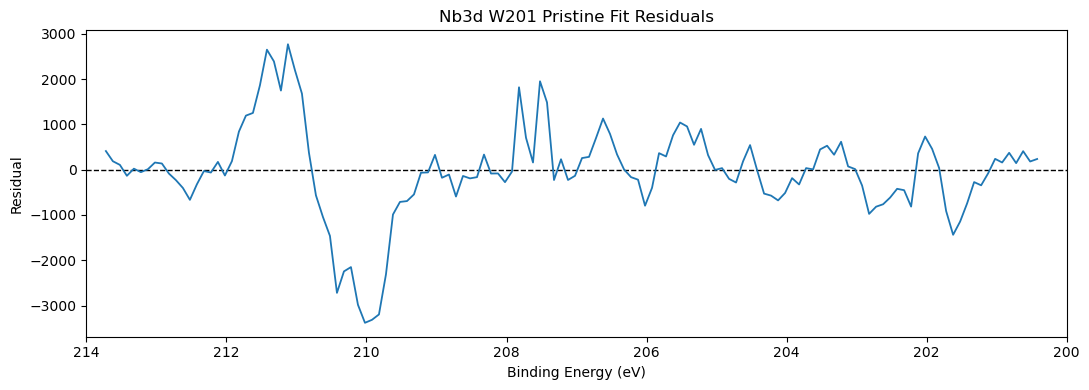

,Component,Area,Area 1-sigma,Shifted position (eV),Position 1-sigma (eV),FWHM (eV),FWHM 1-sigma (eV)
0,Nb metal,65911.264314,1605.138638,202.200000,0.009475,0.840431,0.020824
1,NbO,6335.110751,865.884624,204.109222,0.076891,1.136106,0.004378
2,NbO2,20376.754268,1126.259014,206.171807,0.033624,1.136106,0.004378
3,Nb2O5,279091.361794,2635.385128,207.622691,0.002127,1.136106,0.004378


Residual standard deviation = 1027.605912

Oxide line-shape uncertainty:
Shared oxide eta = 0.170394 ± 0.022168


In [18]:
# ============================================================
# RESIDUALS AND APPROXIMATE UNCERTAINTIES
# ============================================================

residuals = y - total_model(x, popt)

# ------------------------------------------------------------
# Residual plot
# ------------------------------------------------------------

plt.figure(figsize=(11, 4))

plt.axhline(
    0.0,
    color="black",
    linestyle="--",
    linewidth=1,
)

plt.plot(
    x_shifted,
    residuals,
    linewidth=1.3,
)

plt.xlabel("Binding Energy (eV)")
plt.ylabel("Residual")
plt.title(f"{base_name} Fit Residuals")

# Match the cropped XPS range used in the fit plots
plt.xlim(214, 200)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Approximate covariance and parameter uncertainties
# ------------------------------------------------------------

jacobian = best_result.jac
degrees_of_freedom = max(len(y) - len(popt), 1)

try:
    covariance = np.linalg.pinv(
        jacobian.T @ jacobian
    )

    covariance *= (
        2.0
        * best_result.cost
        / degrees_of_freedom
    )

    parameter_std = np.sqrt(
        np.clip(
            np.diag(covariance),
            0.0,
            None,
        )
    )

except np.linalg.LinAlgError:
    covariance = np.full(
        (len(popt), len(popt)),
        np.nan,
    )

    parameter_std = np.full_like(
        popt,
        np.nan,
        dtype=float,
    )


# ------------------------------------------------------------
# Extract parameter uncertainties
# ------------------------------------------------------------

area_indices_array = np.asarray(
    area_indices,
    dtype=int,
)

center_indices_array = np.asarray(
    center_indices,
    dtype=int,
)

area_std = parameter_std[
    area_indices_array
]

position_std = parameter_std[
    center_indices_array
]

metal_fwhm_std = (
    parameter_std[2]
    * METAL_FWHM_CALIBRATION
)

shared_oxide_fwhm_std = parameter_std[3]
shared_oxide_eta_std = parameter_std[4]


# ------------------------------------------------------------
# Results table
# ------------------------------------------------------------

uncertainty_table = pd.DataFrame({
    "Component": component_names,

    "Area": fitted_areas,

    "Area 1-sigma": area_std,

    "Shifted position (eV)": shifted_centers,

    "Position 1-sigma (eV)": position_std,

    "FWHM (eV)": [
        metal_fwhm_reported,
        shared_oxide_fwhm,
        shared_oxide_fwhm,
        shared_oxide_fwhm,
    ],

    "FWHM 1-sigma (eV)": [
        metal_fwhm_std,
        shared_oxide_fwhm_std,
        shared_oxide_fwhm_std,
        shared_oxide_fwhm_std,
    ],
})

display(uncertainty_table)

print(
    f"Residual standard deviation = "
    f"{np.std(residuals, ddof=1):.6f}"
)

print(
    "\nOxide line-shape uncertainty:"
)

print(
    f"Shared oxide eta = "
    f"{shared_oxide_eta:.6f} ± "
    f"{shared_oxide_eta_std:.6f}"
)